# ClearBank — Análise Financeira com Python

**Desafio final do módulo.** Notebook que lê, valida e analisa o histórico de
transações exportado pela equipe de operações (`transacoes.csv`), gera métricas
financeiras mensais, sinaliza transações suspeitas, exibe um relatório no
terminal e salva o resultado em `relatorio.json`.

## Como executar
Rode as células **em ordem, de cima para baixo**. A última célula
(*Célula de Execução Principal*) orquestra todas as funções e produz o relatório
final + o `relatorio.json`.

## Sobre o arquivo de entrada
`transacoes.csv` — 1000 registros (750 válidos, 250 inválidos, 100 acima de
R$ 10.000), distribuídos de jan/2026 a jun/2026. Os registros inválidos cobrem
os 5 tipos de erro tratados na validação: `id` vazio/não numérico,
`cliente_id` vazio, `data` mal formatada, `tipo` inválido e `valor` inválido.

| Coluna | Tipo | Regra |
|---|---|---|
| id | inteiro | único, numérico |
| data | texto | formato `AAAA-MM-DD` |
| cliente_id | texto | não pode ser vazio |
| tipo | texto | `credito` ou `debito` |
| valor | decimal | > 0 |
| descricao | texto | livre |
| categoria | texto | livre |

> **Notebook completo.** Fluxo implementado de ponta a ponta: leitura → validação
> → datas → métricas → relatório no terminal → exportação em JSON, mais os
> requisitos opcionais (pandas em `analise_pandas.py` e gráfico em `grafico.png`).

## 0. Imports e constantes

In [1]:
import csv
import json
from datetime import datetime, date

# --- Constantes de configuração ---
ARQUIVO_CSV = "transacoes.csv"
ARQUIVO_JSON = "relatorio.json"
LIMITE_SUSPEITO = 10000.00   # transações acima deste valor são sinalizadas
FORMATO_DATA = "%Y-%m-%d"


## 1. Leitura do arquivo CSV
Lê o arquivo com o módulo `csv` nativo (sem pandas), usando `DictReader` para
acessar as colunas pelo nome. Trata `FileNotFoundError`.

In [2]:
def ler_transacoes(caminho=ARQUIVO_CSV):
    """Lê o CSV e retorna a lista de transações brutas (dicionários).

    Usa csv.DictReader para acessar colunas pelo nome. Se o arquivo não
    existir, captura FileNotFoundError, avisa o usuário e retorna lista vazia.

    Args:
        caminho (str): caminho do arquivo CSV de entrada.

    Returns:
        list[dict]: linhas brutas, sem validação.
    """
    # try/except nº 1: abertura do arquivo
    try:
        with open(caminho, newline="", encoding="utf-8") as f:
            return list(csv.DictReader(f))
    except FileNotFoundError:
        print(f"ERRO: arquivo '{caminho}' não encontrado. "
              f"Verifique se ele está na mesma pasta do notebook.")
        return []


In [3]:
# Teste rápido — Parte 1
brutas = ler_transacoes()
print(f"Linhas lidas: {len(brutas)}")
print("Primeira linha bruta:", brutas[0] if brutas else "(vazio)")

Linhas lidas: 1000
Primeira linha bruta: {'id': '  ', 'data': '2026-05-23', 'cliente_id': 'CLI023', 'tipo': 'credito', 'valor': '1053.17', 'descricao': 'TED recebida', 'categoria': 'transferencia'}


## 2. Validação e limpeza
Valida cada linha. Descarta silenciosamente as inválidas. Funções pequenas e
reutilizáveis para validar data e valor isoladamente.

In [4]:
def validar_data(texto):
    """Valida e converte uma data texto -> objeto datetime.

    Args:
        texto (str): data no formato AAAA-MM-DD.

    Returns:
        datetime | None: objeto datetime se válida, None caso contrário.
    """
    # try/except nº 2: conversão de data com strptime
    try:
        return datetime.strptime(texto.strip(), FORMATO_DATA)
    except (ValueError, TypeError, AttributeError):
        return None


def validar_valor(texto):
    """Valida e converte o valor texto -> float (> 0).

    Args:
        texto (str): valor monetário.

    Returns:
        float | None: float positivo se válido, None caso contrário.
    """
    # try/except nº 3: conversão de valor para float
    try:
        valor = float(texto)
    except (ValueError, TypeError):
        return None
    return valor if valor > 0 else None


def validar_transacao(linha):
    """Valida uma única linha bruta e retorna o registro limpo.

    Regras de descarte: id vazio/não numérico, cliente_id vazio,
    data inválida, tipo != credito/debito, valor não numérico ou <= 0.
    O tipo é comparado de forma ESTRITA (sem normalizar maiúsculas/espaços),
    seguindo o enunciado: qualquer coisa diferente de 'credito'/'debito' é
    descartada.

    Args:
        linha (dict): linha bruta vinda do DictReader.

    Returns:
        dict | None: registro limpo (com 'valor' float, 'data' datetime,
        'mes' AAAA-MM) se válido; None se a linha for descartada.
    """
    # 1) id vazio ou não numérico
    id_txt = str(linha.get("id", "")).strip()
    if not id_txt.isdigit():
        return None
    # 2) cliente_id vazio
    if not linha.get("cliente_id", "").strip():
        return None
    # 3) data em formato inválido
    dt = validar_data(linha.get("data", ""))
    if dt is None:
        return None
    # 4) tipo diferente de credito/debito
    if linha.get("tipo") not in ("credito", "debito"):
        return None
    # 5) valor não numérico ou <= 0
    valor = validar_valor(linha.get("valor", ""))
    if valor is None:
        return None

    return {
        "id": int(id_txt),
        "data": dt,                       # objeto datetime
        "mes": dt.strftime("%Y-%m"),      # AAAA-MM, usado no agrupamento
        "cliente_id": linha["cliente_id"].strip(),
        "tipo": linha["tipo"],
        "valor": valor,                   # float
        "descricao": linha.get("descricao", ""),
        "categoria": linha.get("categoria", ""),
    }


In [5]:
# Teste rápido — Parte 2 (resumo da limpeza)
validas, invalidas = [], 0
for ln in brutas:
    limpa = validar_transacao(ln)
    if limpa:
        validas.append(limpa)
    else:
        invalidas += 1

print(f"Total de linhas lidas: {len(brutas)}")
print(f"Linhas válidas: {len(validas)}")
print(f"Linhas inválidas: {invalidas}")
print()
print("Exemplo de registro limpo:")
print(validas[0])

Total de linhas lidas: 1000
Linhas válidas: 750
Linhas inválidas: 250

Exemplo de registro limpo:
{'id': 666, 'data': datetime.datetime(2026, 2, 10, 0, 0), 'mes': '2026-02', 'cliente_id': 'CLI033', 'tipo': 'debito', 'valor': 10582.25, 'descricao': 'Streaming', 'categoria': 'assinatura'}


## 3. Manipulação de datas
Extrai o mês (`AAAA-MM`) de cada transação e calcula o período coberto
(dias entre a transação mais antiga e a mais recente).

In [6]:
def calcular_periodo(transacoes):
    """Calcula o período coberto pelas transações válidas.

    Args:
        transacoes (list[dict]): transações válidas (campo 'data' = datetime).

    Returns:
        tuple[datetime, datetime, int]: (mais_antiga, mais_recente, dias_entre).
    """
    datas = [t["data"] for t in transacoes]
    mais_antiga = min(datas)
    mais_recente = max(datas)
    dias_entre = (mais_recente - mais_antiga).days
    return mais_antiga, mais_recente, dias_entre


In [7]:
# Teste rápido — Parte 3
antiga, recente, dias = calcular_periodo(validas)
print(f"Transação mais antiga: {antiga.date()}")
print(f"Transação mais recente: {recente.date()}")
print(f"Dias entre a mais antiga e a mais recente: {dias}")

Transação mais antiga: 2026-01-01
Transação mais recente: 2026-06-30
Dias entre a mais antiga e a mais recente: 180


## 4. Agrupamento mensal e métricas
Para cada mês: quantidade, total crédito, total débito, saldo, média, maior e
menor valor. Também identifica as transações suspeitas (> LIMITE_SUSPEITO).

In [8]:
def gerar_relatorio(transacoes):
    """Agrupa as transações por mês e calcula as métricas.

    Args:
        transacoes (list[dict]): transações válidas.

    Returns:
        dict: {
            "resumo_mensal": { "AAAA-MM": {quantidade, total_credito,
                total_debito, saldo, media, maior_valor, menor_valor}, ... },
            "suspeitas": [ {id, cliente_id, data, valor}, ... ]
        }
    """
    resumo = {}
    suspeitas = []

    for t in transacoes:
        mes = t["mes"]
        # inicializa o mês na primeira vez que aparece
        if mes not in resumo:
            resumo[mes] = {
                "quantidade": 0,
                "total_credito": 0.0,
                "total_debito": 0.0,
                "saldo": 0.0,
                "media": 0.0,
                "maior_valor": t["valor"],
                "menor_valor": t["valor"],
            }
        r = resumo[mes]
        r["quantidade"] += 1
        if t["tipo"] == "credito":
            r["total_credito"] += t["valor"]
        else:
            r["total_debito"] += t["valor"]
        # maior/menor valor do mês (independente do tipo)
        r["maior_valor"] = max(r["maior_valor"], t["valor"])
        r["menor_valor"] = min(r["menor_valor"], t["valor"])

        # detecção de suspeitas (exibição fica na Parte 5)
        if t["valor"] > LIMITE_SUSPEITO:
            suspeitas.append({
                "id": t["id"],
                "cliente_id": t["cliente_id"],
                "data": t["data"].strftime(FORMATO_DATA),
                "valor": t["valor"],
            })

    # fecha as métricas derivadas (saldo, média) e arredonda para 2 casas
    for r in resumo.values():
        soma = r["total_credito"] + r["total_debito"]
        r["saldo"] = round(r["total_credito"] - r["total_debito"], 2)
        r["media"] = round(soma / r["quantidade"], 2)
        for chave in ("total_credito", "total_debito", "maior_valor", "menor_valor"):
            r[chave] = round(r[chave], 2)

    # ordena os meses cronologicamente e as suspeitas por data
    resumo = {mes: resumo[mes] for mes in sorted(resumo)}
    suspeitas.sort(key=lambda s: (s["data"], s["id"]))

    return {"resumo_mensal": resumo, "suspeitas": suspeitas}


In [9]:
# Teste rápido — Parte 4
rel = gerar_relatorio(validas)
print("Meses encontrados:", list(rel["resumo_mensal"].keys()))
print()
print("Métricas de 2026-01:")
for chave, valor in rel["resumo_mensal"]["2026-01"].items():
    print(f"  {chave}: {valor}")
print()
print(f"Transações suspeitas detectadas: {len(rel['suspeitas'])}")

Meses encontrados: ['2026-01', '2026-02', '2026-03', '2026-04', '2026-05', '2026-06']

Métricas de 2026-01:
  quantidade: 116
  total_credito: 298131.28
  total_debito: 475698.9
  saldo: -177567.62
  media: 6670.95
  maior_valor: 55895.1
  menor_valor: 188.84

Transações suspeitas detectadas: 100


## 5. Exibição formatada no terminal
Relatório legível: separadores, valores em R$ no padrão brasileiro, período
analisado, totais de válidas/inválidas e lista de suspeitas.

In [10]:
def fmt_moeda(valor):
    """Formata um número no padrão monetário brasileiro: R$ 1.234,56."""
    return f"R$ {valor:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")


def exibir_relatorio(relatorio, total_validas, total_invalidas, periodo):
    """Imprime o relatório completo e formatado no terminal.

    Args:
        relatorio (dict): saída de gerar_relatorio().
        total_validas (int): nº de transações válidas.
        total_invalidas (int): nº de transações inválidas.
        periodo (tuple): (mais_antiga, mais_recente, dias_entre).
    """
    antiga, recente, dias = periodo

    # --- cabeçalho / resumo da análise ---
    print("=" * 40)
    print("       ANÁLISE FINANCEIRA — ClearBank")
    print("=" * 40)
    print(f"Período analisado: {antiga.date()} → {recente.date()} ({dias} dias)")
    print(f"Transações válidas:   {total_validas}")
    print(f"Transações inválidas: {total_invalidas}")
    print()

    # --- relatório mensal ---
    print("===== RELATÓRIO MENSAL =====")
    for mes, r in relatorio["resumo_mensal"].items():
        print()
        print(f"Mês: {mes}")
        print(f"  {'Transações:':<15}{r['quantidade']}")
        print(f"  {'Total crédito:':<15}{fmt_moeda(r['total_credito'])}")
        print(f"  {'Total débito:':<15}{fmt_moeda(r['total_debito'])}")
        print(f"  {'Saldo:':<15}{fmt_moeda(r['saldo'])}")
        print(f"  {'Média:':<15}{fmt_moeda(r['media'])}")
        print(f"  {'Maior valor:':<15}{fmt_moeda(r['maior_valor'])}")
        print(f"  {'Menor valor:':<15}{fmt_moeda(r['menor_valor'])}")

    # --- transações suspeitas ---
    print()
    print("===== TRANSAÇÕES SUSPEITAS =====")
    suspeitas = relatorio["suspeitas"]
    if not suspeitas:
        print("Nenhuma transação suspeita encontrada.")
    else:
        for s in suspeitas:
            print(f"ID: {s['id']} | Cliente: {s['cliente_id']} | "
                  f"Data: {s['data']} | Valor: {fmt_moeda(s['valor'])}")


### Teste da exibição
Chama `exibir_relatorio` com os dados já processados. Como há 100 transações
acima de R$ 10.000, a seção de suspeitas é longa — isso é esperado para este
conjunto de dados.

In [11]:
# Teste rápido — Parte 5
periodo = calcular_periodo(validas)
exibir_relatorio(rel, len(validas), invalidas, periodo)

       ANÁLISE FINANCEIRA — ClearBank
Período analisado: 2026-01-01 → 2026-06-30 (180 dias)
Transações válidas:   750
Transações inválidas: 250

===== RELATÓRIO MENSAL =====

Mês: 2026-01
  Transações:    116
  Total crédito: R$ 298.131,28
  Total débito:  R$ 475.698,90
  Saldo:         R$ -177.567,62
  Média:         R$ 6.670,95
  Maior valor:   R$ 55.895,10
  Menor valor:   R$ 188,84

Mês: 2026-02
  Transações:    122
  Total crédito: R$ 253.372,52
  Total débito:  R$ 373.854,19
  Saldo:         R$ -120.481,67
  Média:         R$ 5.141,20
  Maior valor:   R$ 54.306,20
  Menor valor:   R$ 43,80

Mês: 2026-03
  Transações:    117
  Total crédito: R$ 416.113,85
  Total débito:  R$ 438.828,09
  Saldo:         R$ -22.714,24
  Média:         R$ 7.307,20
  Maior valor:   R$ 59.433,30
  Menor valor:   R$ 136,92

Mês: 2026-04
  Transações:    119
  Total crédito: R$ 463.592,61
  Total débito:  R$ 297.780,26
  Saldo:         R$ 165.812,35
  Média:         R$ 6.398,09
  Maior valor:   R$ 57.577

## 6. Exportação do relatório em JSON
Salva em `relatorio.json` com `ensure_ascii=False, indent=2`.

In [12]:
def salvar_json(relatorio, total_validas, total_invalidas, caminho=ARQUIVO_JSON):
    """Salva o relatório em JSON formatado (UTF-8, indentado).

    Estrutura: gerado_em, total_transacoes_validas, total_transacoes_invalidas,
    resumo_mensal, transacoes_suspeitas.

    Args:
        relatorio (dict): saída de gerar_relatorio().
        total_validas (int), total_invalidas (int).
        caminho (str): arquivo de saída.
    """
    dados = {
        "gerado_em": date.today().isoformat(),
        "total_transacoes_validas": total_validas,
        "total_transacoes_invalidas": total_invalidas,
        "resumo_mensal": relatorio["resumo_mensal"],
        "transacoes_suspeitas": relatorio["suspeitas"],
    }
    with open(caminho, "w", encoding="utf-8") as f:
        json.dump(dados, f, ensure_ascii=False, indent=2)
    print(f"Arquivo '{caminho}' gerado com sucesso.")


## Célula de Execução Principal
Orquestra todas as funções: leitura → validação → período → métricas →
relatório no terminal → JSON. Roda do início ao fim e gera o `relatorio.json`.

In [13]:
def main():
    """Pipeline completo do desafio."""
    # 1. Leitura
    brutas = ler_transacoes()

    # 2. Validação
    validas, invalidas = [], 0
    for ln in brutas:
        limpa = validar_transacao(ln)
        if limpa:
            validas.append(limpa)
        else:
            invalidas += 1

    # resumo da limpeza
    print(f"Total de linhas lidas: {len(brutas)}")
    print(f"Linhas válidas: {len(validas)}")
    print(f"Linhas inválidas: {invalidas}")
    print()

    # 3. Período
    periodo = calcular_periodo(validas)

    # 4. Métricas + suspeitas
    relatorio = gerar_relatorio(validas)

    # 5. Terminal
    exibir_relatorio(relatorio, len(validas), invalidas, periodo)
    print()

    # 6. JSON
    salvar_json(relatorio, len(validas), invalidas)


main()


Total de linhas lidas: 1000
Linhas válidas: 750
Linhas inválidas: 250

       ANÁLISE FINANCEIRA — ClearBank
Período analisado: 2026-01-01 → 2026-06-30 (180 dias)
Transações válidas:   750
Transações inválidas: 250

===== RELATÓRIO MENSAL =====

Mês: 2026-01
  Transações:    116
  Total crédito: R$ 298.131,28
  Total débito:  R$ 475.698,90
  Saldo:         R$ -177.567,62
  Média:         R$ 6.670,95
  Maior valor:   R$ 55.895,10
  Menor valor:   R$ 188,84

Mês: 2026-02
  Transações:    122
  Total crédito: R$ 253.372,52
  Total débito:  R$ 373.854,19
  Saldo:         R$ -120.481,67
  Média:         R$ 5.141,20
  Maior valor:   R$ 54.306,20
  Menor valor:   R$ 43,80

Mês: 2026-03
  Transações:    117
  Total crédito: R$ 416.113,85
  Total débito:  R$ 438.828,09
  Saldo:         R$ -22.714,24
  Média:         R$ 7.307,20
  Maior valor:   R$ 59.433,30
  Menor valor:   R$ 136,92

Mês: 2026-04
  Transações:    119
  Total crédito: R$ 463.592,61
  Total débito:  R$ 297.780,26
  Saldo:       

---
## (Opcional · RO2) Visualização com matplotlib
Gráfico de barras empilhadas com crédito e débito por mês, salvo como
`grafico.png`. Requer matplotlib (já presente no Google Colab).

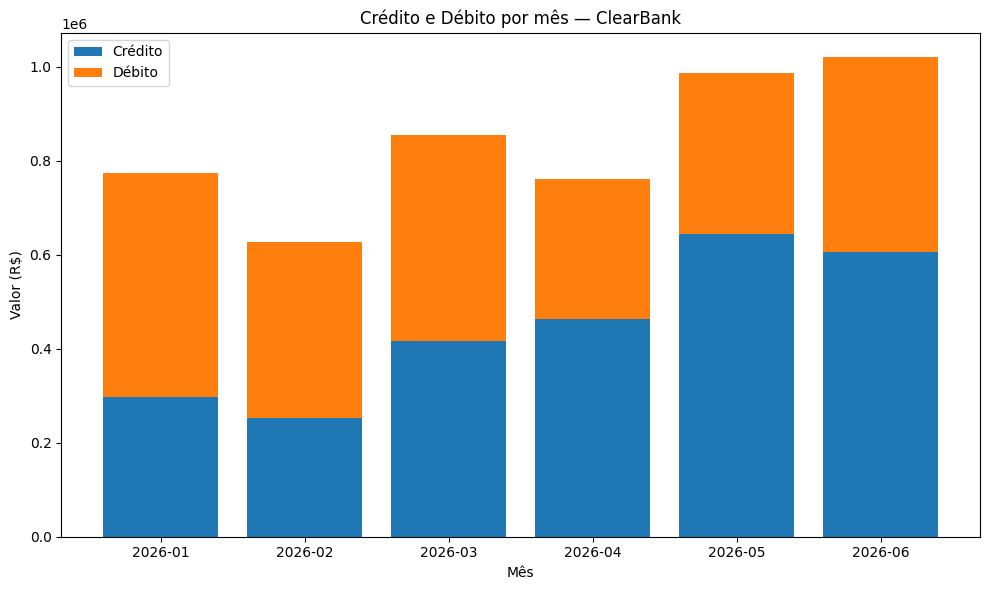

grafico.png salvo.


In [14]:
import matplotlib.pyplot as plt

resumo = rel["resumo_mensal"]
meses = list(resumo.keys())
creditos = [resumo[m]["total_credito"] for m in meses]
debitos = [resumo[m]["total_debito"] for m in meses]

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(meses, creditos, label="Crédito")
ax.bar(meses, debitos, bottom=creditos, label="Débito")
ax.set_title("Crédito e Débito por mês — ClearBank")
ax.set_xlabel("Mês")
ax.set_ylabel("Valor (R$)")
ax.legend()
plt.tight_layout()
plt.savefig("grafico.png", dpi=120)
plt.show()
print("grafico.png salvo.")


## (Opcional · RO1) Análise com pandas
A versão alternativa usando `pandas` (`pd.read_csv` + `groupby`) está no arquivo
separado **`analise_pandas.py`**, conforme pede o enunciado. Ela recalcula as
métricas mensais e as compara com o `relatorio.json` gerado por este notebook —
os valores devem ser idênticos.

In [15]:
import sys

# Executa a versão pandas (arquivo separado) e compara com a solução nativa.
# Precisa do relatorio.json já gerado pela Célula de Execução Principal acima.
# !{sys.executable} usa o mesmo Python do notebook (funciona no Colab e local).
!{sys.executable} analise_pandas.py

Linhas válidas: 750 | inválidas: 250

===== RESUMO MENSAL (pandas) =====

Mês: 2026-01
  quantidade: 116
  total_credito: 298131.28
  total_debito: 475698.9
  saldo: -177567.62
  media: 6670.95
  maior_valor: 55895.1
  menor_valor: 188.84

Mês: 2026-02
  quantidade: 122
  total_credito: 253372.52
  total_debito: 373854.19
  saldo: -120481.67
  media: 5141.2
  maior_valor: 54306.2
  menor_valor: 43.8

Mês: 2026-03
  quantidade: 117
  total_credito: 416113.85
  total_debito: 438828.09
  saldo: -22714.24
  media: 7307.2
  maior_valor: 59433.3
  menor_valor: 136.92

Mês: 2026-04
  quantidade: 119
  total_credito: 463592.61
  total_debito: 297780.26
  saldo: 165812.35
  media: 6398.09
  maior_valor: 57577.0
  menor_valor: 17.68

Mês: 2026-05
  quantidade: 133
  total_credito: 644031.99
  total_debito: 342920.82
  saldo: 301111.17
  media: 7420.7
  maior_valor: 54843.86
  menor_valor: 12.88

Mês: 2026-06
  quantidade: 143
  total_credito: 604713.74
  total_debito: 415904.91
  saldo: 188808.8